# Advanced Heirarchical Clustering

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## Importing Dataset

In [2]:
data = pd.read_csv("/Users/anshumaansoni/PycharmProjects/Machine-Learning/Datasets/Iris.csv")

In [3]:
y = data["Species"]
X = data.drop(columns=["Id", "Species"])

In [4]:
display(data)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


## StandardScaler

In [5]:
sc = StandardScaler()
X = sc.fit_transform(X)

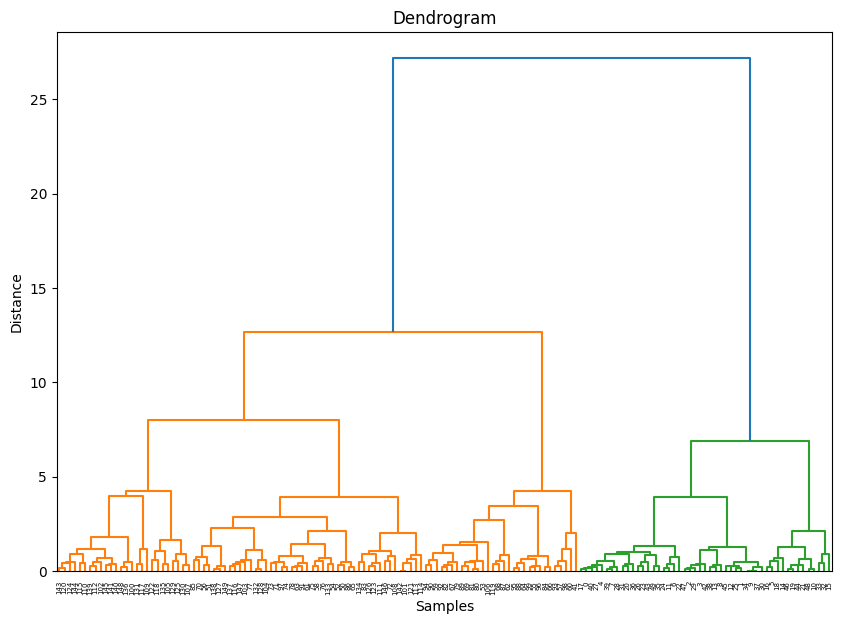

In [6]:
linked = linkage(X, method="ward")
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation="top", distance_sort="descending", show_leaf_counts=True)
plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

## Agglomerative Clustering

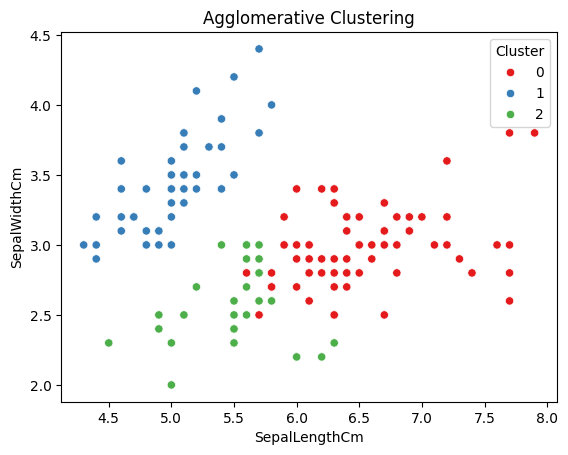

In [8]:
hc = AgglomerativeClustering(n_clusters=3, linkage="ward")
y_hc = hc.fit_predict(X)

data["Cluster"] = y_hc
sns.scatterplot(x=data["SepalLengthCm"], y=data["SepalWidthCm"], hue=data["Cluster"], palette="Set1")
plt.title("Agglomerative Clustering")
plt.show()

In [10]:
hc_score = silhouette_score(X, y_hc)
print(f"Silhouette Score for Agglomerative Clustering: {hc_score}")

Silhouette Score for Agglomerative Clustering: 0.44553956399200406


## Kmeans for Comparison

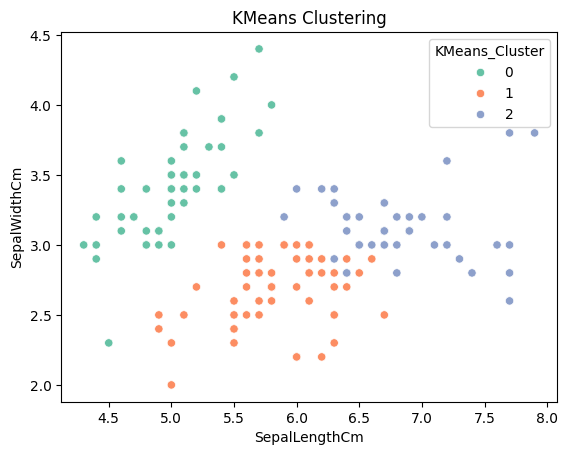

In [11]:
kmean = KMeans(n_clusters=3, random_state=234)
y_kmean = kmean.fit_predict(X)

data["KMeans_Cluster"] = y_kmean
sns.scatterplot(x=data["SepalLengthCm"], y=data["SepalWidthCm"], hue=data["KMeans_Cluster"], palette="Set2")
plt.title("KMeans Clustering")
plt.show()

In [12]:
kmean_score = silhouette_score(X, y_kmean)
print(f"Silhouette Score for KMeans Clustering: {kmean_score}")

Silhouette Score for KMeans Clustering: 0.46214947389312017
